Loaded cached Figure 2C inputs from: Figure2_C_cached_inputs.npz
all_vectors: (31847, 60)
all_spikes_label: (31847, 1)
UMAP(min_dist=0.2, n_epochs=100, n_jobs=1, random_state=42, verbose=True)
Fri Sep 18 16:16:11 2026 Construct fuzzy simplicial set
Fri Sep 18 16:16:11 2026 Finding Nearest Neighbors
Fri Sep 18 16:16:11 2026 Building RP forest with 14 trees


/Users/dazhang/opt/anaconda3/envs/klab_cpu/lib/python3.9/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
OMP: Info #271: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


Fri Sep 18 16:16:13 2026 NN descent for 15 iterations
	 1  /  15
	 2  /  15
	 3  /  15
	 4  /  15
	Stopping threshold met -- exiting after 4 iterations
Fri Sep 18 16:16:19 2026 Finished Nearest Neighbor Search
Fri Sep 18 16:16:21 2026 Construct embedding


Epochs completed:   0%|            0/100 [00:00]

	completed  0  /  100 epochs
	completed  10  /  100 epochs
	completed  20  /  100 epochs
	completed  30  /  100 epochs
	completed  40  /  100 epochs
	completed  50  /  100 epochs
	completed  60  /  100 epochs
	completed  70  /  100 epochs
	completed  80  /  100 epochs
	completed  90  /  100 epochs
Fri Sep 18 16:16:29 2026 Finished embedding


/Users/dazhang/opt/anaconda3/envs/klab_cpu/lib/python3.9/site-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Min X, Max X:  -4.0565567 9.928968
Min Y, Max Y:  0.6404391 12.523612


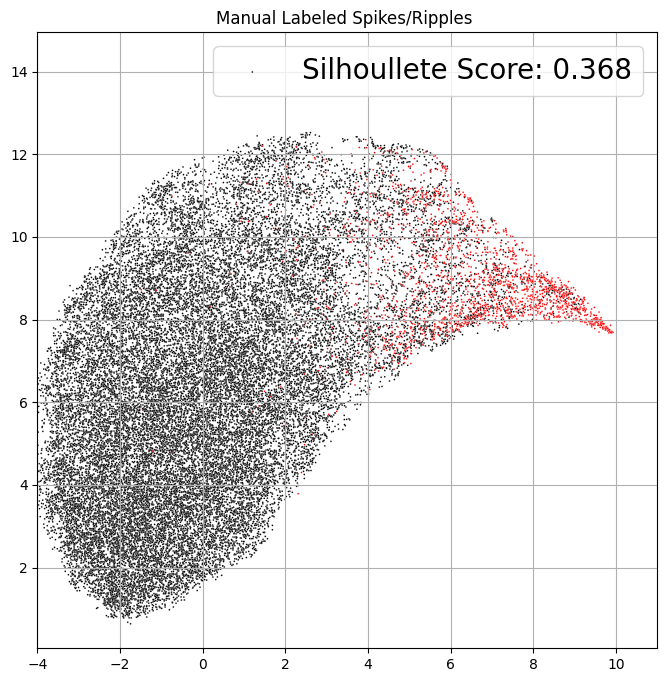

In [1]:
# ============================================================
# Fast reproducible start for Figure 2C.
# After the cache has been created once, start directly here.
# ============================================================
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import umap.umap_ as umap

from sklearn.cluster import KMeans
from sklearn.metrics import pairwise_distances_argmin_min, silhouette_score
from sklearn.preprocessing import normalize

CACHE_FILE = "Figure2_C_cached_inputs.npz"
with np.load(CACHE_FILE, allow_pickle=False) as cached:
    all_vectors = cached["all_vectors"]
    all_spikes_label = cached["all_spikes_label"]

print(f"Loaded cached Figure 2C inputs from: {CACHE_FILE}")
print("all_vectors:", all_vectors.shape)
print("all_spikes_label:", all_spikes_label.shape)

def kl_divergence(p, q, eps=1e-10):
    p = np.clip(p, eps, 1)
    q = np.clip(q, eps, 1)
    return np.sum(p * np.log(p / q))


embedding = umap.UMAP(n_components=2, min_dist=0.2, metric='euclidean',n_neighbors=15,random_state=42, n_epochs=100, verbose=True).fit_transform(all_vectors)

#Import required module
from sklearn.cluster import KMeans
from sklearn.metrics import pairwise_distances_argmin_min
#Initialize the class object
#930 is good
kmeans = KMeans(n_clusters = 5,random_state = 920, n_init=10)

kmeans_label = kmeans.fit(embedding)
closest, all_points_w_labels = pairwise_distances_argmin_min(kmeans_label.cluster_centers_, embedding)

# print(closest)

actual_score = silhouette_score(embedding, all_spikes_label)


def total_kl_divergence(X, labels):
    X = normalize(X, norm='l1', axis=1)  # Ensure all rows are valid distributions
    unique_labels = np.unique(labels)
    total_kl = 0
    labels = np.ravel(labels)

    for label in unique_labels:
        cluster_points = X[labels == label]
        if cluster_points.shape[0] == 0:
            continue
        centroid = np.mean(cluster_points, axis=0)
        centroid /= np.sum(centroid)  # Normalize to make it a distribution

        for x in cluster_points:
            total_kl += kl_divergence(x, centroid)

    return total_kl

total_kl = total_kl_divergence(embedding, all_spikes_label)




# red: spike
# blue: ripple
c_list = []
for i, txt in enumerate(all_spikes_label):
    spike = all_spikes_label[i]
    if spike == 0:
        # cc = [1, 1, 1]  # Whites
        cc = [0, 0, 0]   # Black
    else:
        cc = [1, 0, 0] 
        # cc = [0, 0, 0]
        # cc = [1, 1, 1]
    c_list.append(cc)


max_x = np.max(embedding[:, 0])  # Find the maximum x-coordinate
embedding[embedding[:, 0] == max_x] 
min_x = np.min(embedding[:, 0])  # Find the maximum x-coordinate
embedding[embedding[:, 0] == min_x] 
print("Min X, Max X: ", min_x, max_x)


max_y = np.max(embedding[:, 1])  # Find the maximum x-coordinate
embedding[embedding[:, 0] == max_y] 
min_y = np.min(embedding[:, 1])  # Find the maximum x-coordinate
embedding[embedding[:, 0] == min_y] 
print("Min Y, Max Y: ",min_y, max_y)


fig, ax = plt.subplots(figsize=(8,8))
ax = sns.scatterplot(x=embedding[:,0], y=embedding[:,1], c=c_list, s=1.5)
ax.legend(["Silhoullete Score: "+str(f"{actual_score:.3f}")], fontsize=20, ncol=1)
# ax.legend(["KL Divergence: "+str(f"{total_kl:.3f}")], fontsize=20, ncol=1)

# ax.axvline(x=max_x, color='green', linestyle='--', label=f"Max X = {max_x:.2f}")
# ax.axvline(x=min_x, color='red', linestyle='--', label=f"Min X = {min_x:.2f}")
# ax.text(max_x, ax.get_ylim()[0] - 0.5, f"{max_x:.2f}", ha='center', va='top', fontsize=12, color='green')
# ax.text(min_x, ax.get_ylim()[0] - 0.5, f"{min_x:.2f}", ha='center', va='top', fontsize=12, color='red')

# ax.axhline(y=max_y, color='blue', linestyle='--', label=f"Max Y = {max_y:.2f}")
# ax.axhline(y=min_y, color='orange', linestyle='--', label=f"Min Y = {min_y:.2f}")
# ax.text(ax.get_xlim()[0], max_y, f"{max_y:.2f}", ha='center', va='top', fontsize=12, color='blue')
# ax.text(ax.get_xlim()[0], min_y, f"{min_y:.2f}", ha='center', va='top', fontsize=12, color='orange')

# ax.set_xticklabels([])
# ax.set_yticklabels([])

ax.grid(True)
ax.axis('equal')

ax.set_xlim(-4, 11)
ax.set_ylim(0, 15)
# ax.set_xticklabels([])
# ax.set_yticklabels([])

ax.title.set_text("Manual Labeled Spikes/Ripples ")
plt.show()
# plt.legend()
# plt.savefig("plot_prob_dots_true_200_only_spike.png")
# plt.savefig("plot_prob_dots_true_200.png")
# plt.close()